## Objective

An agent learns to **store as few frames as possible** while still reconstructing a
multi-event sequence. It leverages the within-event autoregressive structure to *skip*
predictable frames and *store* at surprises. Keyframes should emerge at event onsets.

### Data
Stable features = event **identity** (constant-ish per event); autoreg features = within-event
trajectory (OU ramp toward 0 or 1). Variable event lengths. Boundaries come from cumulative
lengths, not fixed spacing.

In [13]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');
from utils import generate_stim

def stim2tensor(stim): return torch.tensor(stim, dtype=torch.float32)

# data params
stim_dim, n_stims, min_events, max_events, prop_related_events = 10, 50, 5, 5, 0     # stim-vector dim
# model params
hidden_dim, recon_wt, LR, num_models = 64, 7, 1e-4, 3
# seeds
rng = np.random.default_rng(42)
seeds = rng.choice(1000, size=30, replace=False)

# data
all_data = []
for s in seeds:
    stim_info = generate_stim(stim_dim=stim_dim, n_stims=n_stims, min_events=min_events, max_events=max_events, prop_related_events=prop_related_events, seed=s)
    all_data.append((stim2tensor(stim_info['stim']), stim_info['event_boundaries']))
train_ids, test_ids, eval_ids = list(range(20)), list(range(20, 25)), list(range(25, 30))
train_data, test_data, eval_data = [all_data[i] for i in train_ids], [all_data[i] for i in test_ids], [all_data[i] for i in eval_ids]
train_stims, test_stims, eval_stims = [stim for stim, _ in train_data], [stim for stim, _ in test_data], [stim for stim, _ in eval_data]

any random stim (time, features): torch.Size([50, 10])
its boundaries : [ 0  5 17 26 37]


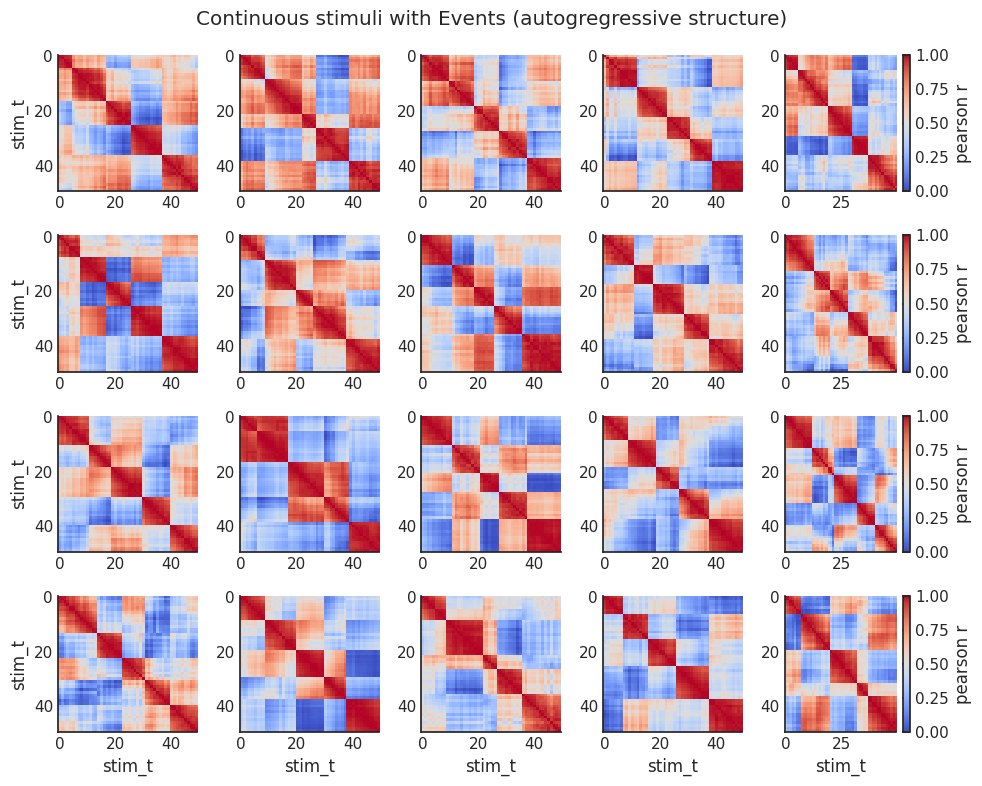

In [14]:
print("any random stim (time, features):", train_stims[0].shape)
print("its boundaries :", train_data[0][1])

fig, axs = plt.subplots(4, 5, figsize=(5*2, 4*2))
axs = axs.flatten()
plt.suptitle('Continuous stimuli with Events (autogregressive structure)')
for i, train_stim in enumerate(train_stims):
    axs[i].set(xlabel='stim_t' if i>14 else '', ylabel='stim_t' if i%5==0 else '' )
    im = axs[i].imshow(norm01(np.corrcoef(train_stim.numpy())), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
                   origin='upper', interpolation='nearest')
    if i in [4, 9, 14, 19]:    plt.colorbar(im, ax=axs[i], label='pearson r')
    plt.tight_layout()
plt.show()

### Forward walk
On **SKIP** the prediction feeds back in (true autoregressive rollout); on **STORE** the
real frame does, resetting drift — and the hidden memory is hard-reset, so memory only spans
the current event (since the last keyframe). The store gate is a continuous sigmoid in [0,1]
(fully differentiable); it is binarized (> 0.5) only at eval readout.

In [15]:
# binarize_wt = 0.1  # weight for keyframe binarization loss
def forward_walk(stim, predictor, keyframer):  # per stimulus/video
    hidden_memory = torch.zeros(hidden_dim)   # RNN hidden state, reset each video
    reconstruction, keyframe_probabilities = [], []

    # initialize first keyframe; stim[1] serves as context-only (not stored)
    recon_x_prev, recon_x_curr = stim[0], stim[1]
    reconstruction.append(recon_x_prev); reconstruction.append(recon_x_curr)

    for stim_t in range(2, stim.shape[0]):

        # PREDICT: true next stim vs prediction (based on recon_x_prev, recon_x_curr & hidden_memory)
        x_next = stim[stim_t]
        x_pred, hidden_memory = predictor.step(recon_x_prev, recon_x_curr, hidden_memory)

        # KEYFRAME DECISION: sigmoid [0,1]
        keyframe_probability = keyframer(x_next-x_pred)
        keyframe_probabilities.append(keyframe_probability)

        # # depending on keyframe, update reconstruction & hidden memory
        # # cant do if/else to maintain gradient flow
        # recon_stim_new = (keyframe_probability * x_next) + ((1 - keyframe_probability) * x_pred)
        # reconstruction.append(recon_stim_new)
        # recon_x_prev = recon_x_curr; recon_x_curr = recon_stim_new
        # hidden_memory = (1 - keyframe_probability) * hidden_memory        

        # (straight-through) AFTER — add one line, then swap keyframe_probability → store_hard in the two lines below
        store_hard = (keyframe_probability > 0.5).float() - keyframe_probability.detach() + keyframe_probability
        recon_stim_new = (store_hard * x_next) + ((1 - store_hard) * x_pred)
        reconstruction.append(recon_stim_new)
        recon_x_prev = recon_x_curr; recon_x_curr = recon_stim_new
        hidden_memory = (1 - store_hard) * hidden_memory

    reconstruction = torch.stack(reconstruction); keyframe_probabilities = torch.stack(keyframe_probabilities)
    recon_err = F.mse_loss(reconstruction[2:], stim[2:])   # first 2 frames are copies of stim; exclude from error
    # loss = normed(key_probs) + weighted recon_err
    loss = (keyframe_probabilities.sum() / stim[2:].shape[0]) + (recon_wt * recon_err)
    # loss = (keyframe_probabilities.sum() / stim[2:].shape[0]) \
    #  + (recon_wt * recon_err) \
    #  + binarize_wt * (keyframe_probabilities * (1 - keyframe_probabilities)).mean()

    # pad probs to stim length (after loss): t=0 always-stored first keyframe, t=1 context-only
    keyframe_probabilities = torch.cat([torch.tensor([1., 0.]), keyframe_probabilities.detach()])

    return reconstruction, recon_err, keyframe_probabilities, loss
    # return reconstruction, recon_err, keyframe_probabilities.detach(), loss


### Model: predictor + keyframer

In [16]:
class Predictor(nn.Module): # RNN
    """Given a running hidden state, predict the next frame."""
    def __init__(self):
        super().__init__() 
        self.rnn = nn.RNNCell(2 * stim_dim, hidden_dim) # x_prev, x_curr -> h_new
        self.out = nn.Linear(hidden_dim, stim_dim) # -> h_new -> x_next
        
    def step(self, x_prev, x_curr, h):
        h_new = self.rnn(torch.cat([x_prev, x_curr]), h); x_next = self.out(h_new)
        return x_next, h_new
    
class Keyframer(nn.Module): # NN
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential( # run in this order
            nn.Linear(stim_dim, hidden_dim), # x_diff -> hidden
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_diff):
        return torch.sigmoid(self.net(x_diff)).squeeze(-1) # store ∈ [0,1]
    

### Train

In [17]:
def pretrain_step(stim, predictor):
    hidden = torch.zeros(hidden_dim)
    recon, prev, curr = [], stim[0], stim[1]
    for t in range(2, stim.shape[0]):
        x_pred, hidden = predictor.step(prev, curr, hidden)
        recon.append(x_pred)
        prev = curr; curr = stim[t]   # always true frames
    return F.mse_loss(torch.stack(recon), stim[2:])

EPOCHS = 50
all_model_learning, trained_models = [], []

for model_idx in range(num_models):
    torch.manual_seed(1000 + model_idx)   # different init per model; data stays identical across models
    predictor, keyframer = Predictor(), Keyframer()
    
    # PRETRAIN_EPOCHS = 50
    # pred_opt = torch.optim.Adam(predictor.parameters(), lr=LR)
    # for epoch in range(PRETRAIN_EPOCHS):
    #     for stim in train_stims:
    #         loss = pretrain_step(stim, predictor)
    #         pred_opt.zero_grad(); loss.backward(); pred_opt.step()
    # then proceed with the existing joint training loop


    opt = torch.optim.Adam(list(predictor.parameters()) + list(keyframer.parameters()), lr=LR)

    model_learning = {"epoch": [], "train_recon_err": [], "train_memory_mass": [], "train_loss": [],
                                   "test_recon_err": [], "test_memory_mass": [], "test_loss": []}

    for epoch in range(EPOCHS):

        # TRAIN
        train_recon_err, train_memory_mass, train_loss = [], [], []
        for stim in train_stims:
            # forward pass
            reconstruction, recon_err, keyframe_probabilities, loss = forward_walk(stim, predictor, keyframer)
            # clear old gradients, backprop, and update weights
            opt.zero_grad(); loss.backward(); opt.step()
            # append across stims (memory mass = sum of keyframe probabilities)
            train_recon_err.append(recon_err.item()); train_memory_mass.append(keyframe_probabilities.sum().item()); train_loss.append(loss.item())
        # append across epochs
        model_learning["epoch"].append(epoch); model_learning["train_recon_err"].append(np.mean(train_recon_err)); model_learning["train_memory_mass"].append(np.mean(train_memory_mass)); model_learning["train_loss"].append(np.mean(train_loss))

        # TEST
        with torch.no_grad():
            test_recon_err, test_memory_mass, test_loss = [], [], []
            for stim in test_stims:
                # forward pass
                reconstruction, recon_err, keyframe_probabilities, loss = forward_walk(stim, predictor, keyframer) # forward pass
                # append across stims (memory mass = sum of keyframe probabilities)
                test_recon_err.append(recon_err.item()); test_memory_mass.append(keyframe_probabilities.sum().item()); test_loss.append(loss.item())
        # append across epochs
        model_learning["test_recon_err"].append(np.mean(test_recon_err)); model_learning["test_memory_mass"].append(np.mean(test_memory_mass)); model_learning["test_loss"].append(np.mean(test_loss))

    df = pd.DataFrame(model_learning);  df["model_idx"] = model_idx    
    # append results & models
    all_model_learning.append(df);  assert len(df) == EPOCHS
    trained_models.append((predictor, keyframer))

model_learning_df = pd.concat(all_model_learning, ignore_index=True);   model_learning_df.head()

,epoch,train_recon_err,train_memory_mass,train_loss,test_recon_err,test_memory_mass,test_loss,model_idx
0,0,0.305619,22.698411,2.591384,0.297845,23.022378,2.543715,0
1,1,0.257333,23.307443,2.266073,0.241045,23.604644,2.158244,0
2,2,0.196250,23.879858,1.850414,0.171715,24.112462,1.683513,0
3,3,0.138656,24.283035,1.455659,0.122644,24.412423,1.346270,0
4,4,0.105886,24.443406,1.229607,0.102182,24.513522,1.205139,0


### Learning

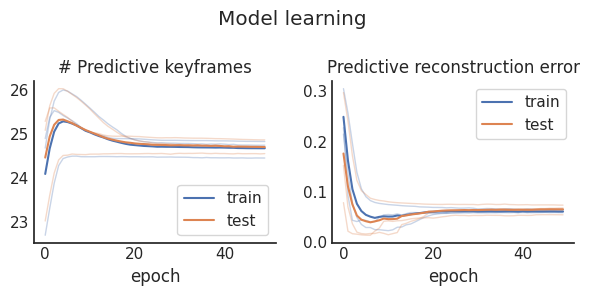

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3));   plt.suptitle('Model learning')

metrics = [("memory_mass", "# Predictive keyframes"), ("recon_err", "Predictive reconstruction error")]
mean_model_results = model_learning_df.groupby("epoch").mean(numeric_only=True)   # avg across models

for ax, (metric, title) in zip(ax, metrics):
    # thin faint line per model (train=blue, test=orange)
    for _, g in model_learning_df.groupby("model_idx"):
        ax.plot(g["epoch"], g[f"train_{metric}"], color="C0", alpha=0.3, lw=1)
        ax.plot(g["epoch"], g[f"test_{metric}"],  color="C1", alpha=0.3, lw=1)
    # bold mean across models
    ax.plot(mean_model_results.index, mean_model_results[f"train_{metric}"], color="C0", lw=1.5, label='train')
    ax.plot(mean_model_results.index, mean_model_results[f"test_{metric}"],  color="C1", lw=1.5, label='test')
    ax.set(title=title, xlabel='epoch'); ax.legend()

plt.tight_layout(); plt.show()

### Model inference across train, test, & eval

In [19]:
infer_on_all_data = []
for model_idx, (predictor, keyframer) in enumerate(trained_models):

    with torch.no_grad():
        # inference on all data (train/test/eval)
        for stim_t, boundaries in all_data:
            reconstruction, recon_err, keyframe_probabilities, loss = forward_walk(stim_t, predictor, keyframer)
            # pick ids where keyframe_probability > 0.5 (t=0 included via its padded prob of 1)
            keyframe_ids = [i for i, key in enumerate(keyframe_probabilities.tolist()) if key > 0.5]
            infer_on_all_data.append((model_idx, stim_t, boundaries, reconstruction, recon_err, keyframe_probabilities, keyframe_ids))

infer_on_all_data_df = pd.DataFrame(infer_on_all_data, columns=["model_idx", "stim", "boundaries", 'reconstruction', 'recon_err', "keyframe_probabilities", "keyframe_ids"])
infer_on_all_data_df.head()

,model_idx,stim,boundaries,reconstruction,recon_err,keyframe_probabilities,keyframe_ids
0,0,"[[tensor(0.3863), tensor(0.9366), tensor(0.494...","[0, 5, 17, 26, 37]","[[tensor(0.3863), tensor(0.9366), tensor(0.494...",tensor(0.0771),"[tensor(1.), tensor(0.), tensor(0.4666), tenso...","[0, 19, 24, 48]"
1,0,"[[tensor(0.1075), tensor(0.8039), tensor(0.460...","[0, 9, 22, 27, 39]","[[tensor(0.1075), tensor(0.8039), tensor(0.460...",tensor(0.0470),"[tensor(1.), tensor(0.), tensor(0.4650), tenso...","[0, 10, 27, 28, 31, 32, 33, 35, 37, 38]"
2,0,"[[tensor(0.2708), tensor(0.3454), tensor(0.697...","[0, 10, 19, 28, 38]","[[tensor(0.2708), tensor(0.3454), tensor(0.697...",tensor(0.0486),"[tensor(1.), tensor(0.), tensor(0.4713), tenso...","[0, 19]"
3,0,"[[tensor(0.4093), tensor(0.5682), tensor(0.407...","[0, 12, 23, 31, 39]","[[tensor(0.4093), tensor(0.5682), tensor(0.407...",tensor(0.0558),"[tensor(1.), tensor(0.), tensor(0.4764), tenso...","[0, 7, 11, 14, 17, 19, 22, 39, 44, 49]"
4,0,"[[tensor(0.0179), tensor(0.7898), tensor(0.116...","[0, 6, 19, 30, 37]","[[tensor(0.0179), tensor(0.7898), tensor(0.116...",tensor(0.0596),"[tensor(1.), tensor(0.), tensor(0.4742), tenso...","[0, 7, 12, 16, 22, 26, 29]"


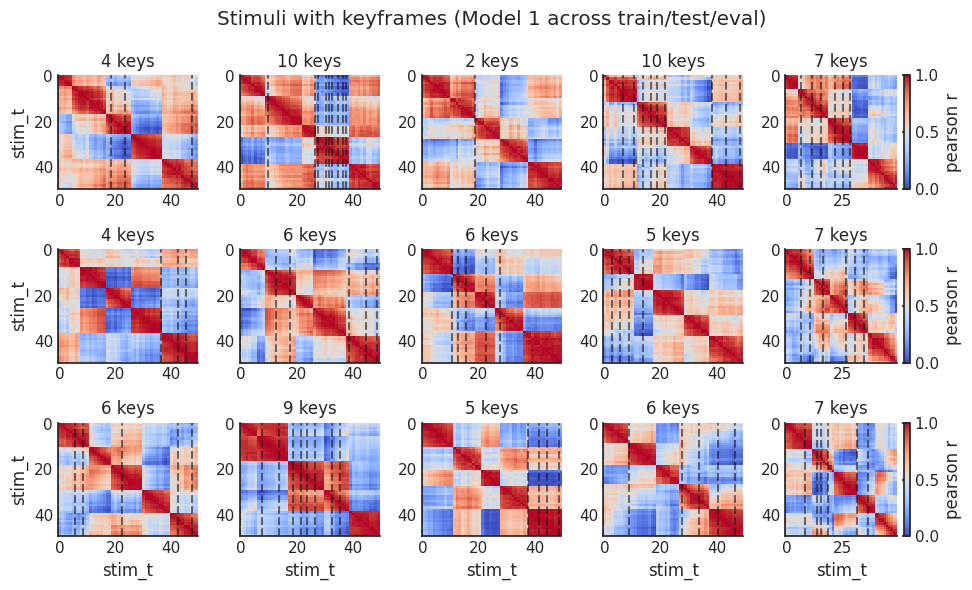

In [20]:
# pick 1 model, and 5 train/test/eval stimuli
model = 0; model_inference = infer_on_all_data_df.query(f"model_idx == {model}").iloc[:-15].reset_index(drop=True)
n_rows, n_cols = 3, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2)); axs = axs.flatten()
plt.suptitle(f'Stimuli with keyframes (Model {model+1} across train/test/eval)')

for i, row in model_inference.iterrows():
    model_idx, stim_t, boundaries, reconstruction, recon_err, keyframe_probabilities, keyframes = row
    axs[i].set(title=f"{len(keyframes)} keys", xlabel="stim_t" if i // n_cols == n_rows - 1 else '', ylabel="stim_t" if i % n_cols == 0 else '')
    im = axs[i].imshow(norm01(np.corrcoef(stim_t.numpy())), aspect='auto', cmap='coolwarm', vmin=0, vmax=1, origin='upper', interpolation='nearest')

    for kf in keyframes:    axs[i].axvline(kf - 0.5, color="k", linestyle="--", alpha=0.6)   # -0.5: cell edge, not center
    if i % n_cols == n_cols - 1:     plt.colorbar(im, ax=axs[i], label="pearson r")
    
plt.tight_layout(); plt.show()

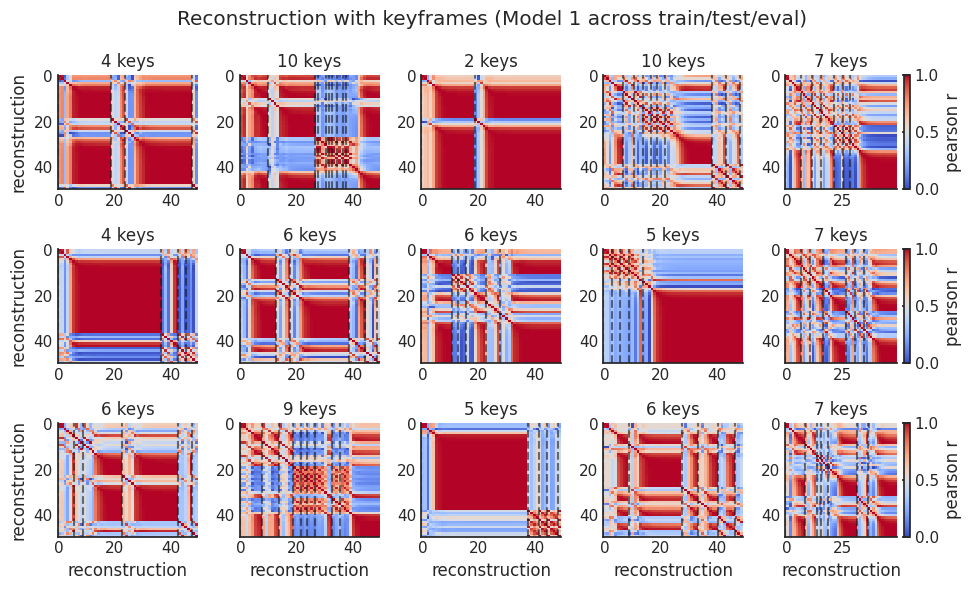

In [21]:
# pick 1 model, and 5 train/test/eval stimuli
model = 0; model_inference = infer_on_all_data_df.query(f"model_idx == {model}").iloc[:-15].reset_index(drop=True)
n_rows, n_cols = 3, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2)); axs = axs.flatten()
plt.suptitle(f'Reconstruction with keyframes (Model {model+1} across train/test/eval)')

for i, row in model_inference.iterrows():
    model_idx, stim_t, boundaries, reconstruction, recon_err, keyframe_probabilities, keyframes = row
    axs[i].set(title=f"{len(keyframes)} keys", xlabel="reconstruction" if i // n_cols == n_rows - 1 else '', ylabel="reconstruction" if i % n_cols == 0 else '')
    im = axs[i].imshow(norm01(np.corrcoef(reconstruction.numpy())), aspect='auto', cmap='coolwarm', vmin=0, vmax=1, origin='upper', interpolation='nearest')

    for kf in keyframes:    axs[i].axvline(kf - 0.5, color="k", linestyle="--", alpha=0.6)   # -0.5: cell edge, not center
    if i % n_cols == n_cols - 1:     plt.colorbar(im, ax=axs[i], label="pearson r")
    
plt.tight_layout(); plt.show()

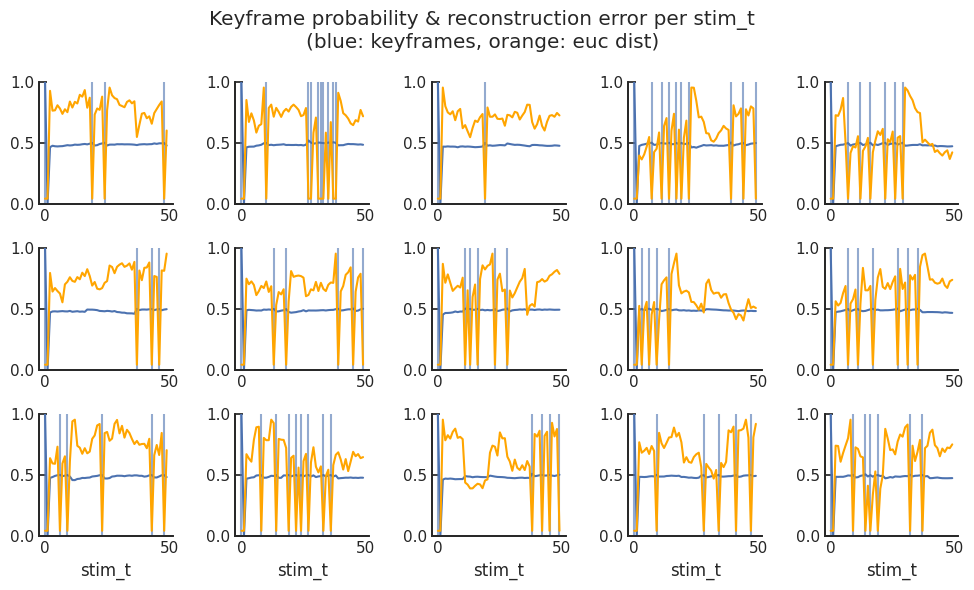

In [22]:
n_rows, n_cols = 3, 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2)); axs = axs.flatten()
plt.suptitle('Keyframe probability & reconstruction error per stim_t\n(blue: keyframes, orange: euc dist)')

for i, row in model_inference.iterrows():
    model_idx, stim_t, boundaries, reconstruction, recon_err, keyframe_probs, keyframes = row
    axs[i].set(ylim=(0, 1), xlabel='stim_t' if i // n_cols == n_rows - 1 else '')
    axs[i].plot(range(len(keyframe_probs)), keyframe_probs, color='b', label='p(key)')
    # for b in boundaries:  axs[i].axvline(b, color='orange', linestyle='-', alpha=0.6)
    for key in keyframes:    axs[i].axvline(key, color="b", linestyle="-", alpha=0.6)

    ax2 = axs[i].twinx()
    euc_dist = torch.norm(stim_t - reconstruction, dim=-1).numpy()
    ax2.plot(range(len(euc_dist)), euc_dist, color='orange', label='euc dist')
    ax2.tick_params(right=False, labelright=False)   # hide right ticks on all but last col

plt.tight_layout(); plt.show()

### Jaccard's/Hamming test

In [23]:
# def overlap_per_tolerance(boundaries, keyframes, T, tol):
#     """Dilate both sets by ±tol frames, then compute Jaccard |B∩K|/|B∪K| and Hamming distance."""
#     bound_mask, key_mask = np.zeros(T, dtype=bool), np.zeros(T, dtype=bool)
#     # dilate
#     for b in boundaries:    bound_mask[max(0, b - tol):min(T, b + tol + 1)] = True
#     for k in keyframes:     key_mask[max(0, k - tol):min(T, k + tol + 1)] = True
#     intersection, union = (bound_mask & key_mask).sum(), (bound_mask | key_mask).sum()
#     jaccard = intersection / union if union > 0 else 0.0
#     hamming = (bound_mask != key_mask).sum()
#     return jaccard, hamming

# N_PERM = 1000
# tolerances = [0, 1, 2, 3, 4]
# model_ids = sorted(eval_results_df["model_idx"].unique())

# # run the full test per model, collect observed + null (one entry per model), then average across models
# np.random.seed(42)
# obs_j  = {tol: [] for tol in tolerances}   # per-model observed Jaccard (avg over its eval stims)
# obs_h  = {tol: [] for tol in tolerances}
# null_j = {tol: [] for tol in tolerances}   # per-model null draws (each a length-N_PERM list)
# null_h = {tol: [] for tol in tolerances}

# for m in model_ids:
#     g = eval_results_df[eval_results_df["model_idx"] == m]
#     # metrics need only (boundaries, keyframes, sequence-length T); the stim tensor isn't used here
#     bound_key_data = [(bounds, keys, stim_t.shape[0])
#                       for stim_t, bounds, keys in zip(g["stim"], g["boundaries"], g["keyframe_ids"])]

#     # observed (per tolerance, averaged across this model's eval stims)
#     for tol in tolerances:
#         obs = [overlap_per_tolerance(bounds, keys, T, tol) for bounds, keys, T in bound_key_data]
#         obs_j[tol].append(np.mean([o[0] for o in obs]))
#         obs_h[tol].append(np.mean([o[1] for o in obs]))

#     # permutation null for this model (one null loop: same random draw feeds both metrics)
#     perm_jaccards = {tol: [] for tol in tolerances}
#     perm_hammings = {tol: [] for tol in tolerances}
#     for _ in range(N_PERM):
#         for tol in tolerances:
#             js, hs = [], []
#             for bounds, keys, T in bound_key_data:
#                 # prepend key=0 so as to not inflate results
#                 permuted_keys = np.concatenate([[0], np.random.choice(np.arange(1, T), size=len(keys) - 1, replace=False)])
#                 j, h = overlap_per_tolerance(bounds, permuted_keys, T, tol)
#                 js.append(j); hs.append(h)
#             perm_jaccards[tol].append(np.mean(js))
#             perm_hammings[tol].append(np.mean(hs))
#     for tol in tolerances:
#         null_j[tol].append(perm_jaccards[tol])
#         null_h[tol].append(perm_hammings[tol])

# print(f"n models = {len(model_ids)}, n eval stims/model = {len(bound_key_data)}")
# print(f"{'tolerance':>9}  {'Jaccard':>8} {'null':>7} {'p':>6}    {'Hamming':>8} {'null':>7} {'p':>6}")
# print("-" * 65)
# for tol in tolerances:
#     j = np.mean(obs_j[tol]); h = np.mean(obs_h[tol])         # observed, averaged across models
#     jn = np.mean(np.array(null_j[tol]), axis=0)              # null, averaged across models -> len N_PERM
#     hn = np.mean(np.array(null_h[tol]), axis=0)
#     # J: higher = more overlap; H: lower = closer
#     print(f"{tol:>9}  {j:>8.3f} {jn.mean():>7.3f} {(jn >= j).mean():>6.3f}"
#           f"    {h:>8.3f} {hn.mean():>7.3f} {(hn <= h).mean():>6.3f}")

### ToDo


* vary n_events, n_models

### Schematic
One unrolled timestep: predict → score → gate → feed back. STORE resets drift with the real frame; SKIP rolls forward on the prediction.

In [24]:
# from matplotlib.patches import FancyBboxPatch

# def _box(ax, xy, w, h, text, fc):
#     x, y = xy
#     ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
#                                 fc=fc, ec="black", lw=1.3, zorder=2))
#     ax.text(x, y, text, ha="center", va="center", fontsize=9, zorder=3)

# def _arrow(ax, p0, p1, text="", rad=0.0, off=(0, 0.25)):
#     ax.annotate("", xy=p1, xytext=p0, zorder=1,
#                 arrowprops=dict(arrowstyle="-|>", lw=1.4, color="0.25",
#                                 connectionstyle=f"arc3,rad={rad}", shrinkA=10, shrinkB=10))
#     if text:
#         mx, my = (p0[0]+p1[0])/2 + off[0], (p0[1]+p1[1])/2 + off[1]
#         ax.text(mx, my, text, ha="center", va="center", fontsize=8, color="0.25")

# fig, ax = plt.subplots(figsize=(13, 6))
# BLUE, GREEN, ORANGE, GREY = "#cfe3f5", "#d6ecd6", "#fbe3c6", "#eeeeee"

# # node centers
# INP, PRED, KEY, GATE = (1.7,3.2),(5.2,3.2),(9.6,3.2),(13.2,3.2)
# YTRUE, ERR, UPD      = (5.2,6.3),(8.7,6.3),(12.6,0.7)

# _box(ax, INP,  2.4, 1.0, "recon_stim[t-1]",                             GREY)
# _box(ax, PRED, 2.8, 1.6, "PREDICTOR\nRNNCell(10→64)\nLinear(64→10)", BLUE)
# _box(ax, YTRUE,1.8, 0.8, "y_true[t]",                                   GREY)
# _box(ax, ERR,  3.0, 0.9, "error = MSE(y_pred, y_true)",                 ORANGE)
# _box(ax, KEY,  2.8, 1.6, "KEYFRAMER\nLinear(21→64) ReLU\nLinear(64→2)",GREEN)
# _box(ax, GATE, 2.6, 1.1, "Gumbel-softmax (hard)\nstore ∈ {0,1}",     ORANGE)
# _box(ax, UPD,  4.6, 1.0, "recon[t] = store·y_true + (1−store)·y_pred",GREY)

# # main horizontal path
# _arrow(ax, INP, PRED, "input")
# _arrow(ax, PRED, KEY, "y_pred")
# _arrow(ax, KEY, GATE, "logits")
# _arrow(ax, GATE, UPD, "store", off=(0.35, 0))
# # error branch (top)
# _arrow(ax, PRED, ERR, "y_pred", rad=0.2, off=(-0.7, 0.55))
# _arrow(ax, YTRUE, ERR, "")
# _arrow(ax, YTRUE, KEY, "y_true", rad=-0.2, off=(0.3, -0.55))
# _arrow(ax, ERR, KEY, "error", off=(0.35, 0))
# # predictor hidden self-loop (hard-reset to 0 on store)
# ax.annotate("", xy=(4.7,4.15), xytext=(5.7,4.15),
#             arrowprops=dict(arrowstyle="-|>", lw=1.3, color="0.25", connectionstyle="arc3,rad=1.7"))
# ax.text(5.2, 5.05, "hidden_memory\n(reset to 0 on store)", ha="center", fontsize=8, color="0.25")
# # feedback loop along the bottom: recon[t] -> input at t+1
# _arrow(ax, UPD, INP, "feed back  (t → t+1)", rad=-0.28, off=(0, -0.35))

# ax.set(xlim=(-0.4, 15.6), ylim=(-0.4, 7.2)); ax.axis("off")
# ax.set_title("Model schematic — one timestep of the predict–gate loop")
# plt.tight_layout(); plt.show()